# 02 - Exploratory Data Analysis (EDA)

## Objetivo

Realizar uma Análise Exploratória de Dados (Exploratory Data Analysis - EDA) com o objetivo de compreender o comportamento das variáveis do conjunto de dados, identificar padrões, relações, possíveis inconsistências e gerar evidências que subsidiem as etapas de preparação dos dados e modelagem preditiva.

---

## Perguntas que desejamos responder

Ao longo desta etapa, busca-se responder:

- Como estão distribuídas as variáveis numéricas?
- Existem valores extremos (outliers)?
- As distribuições apresentam assimetria?
- O tipo do imóvel influencia o valor do aluguel?
- A área do imóvel possui relação com o aluguel?
- Existem bairros com maior concentração de imóveis ou maiores valores de aluguel?
- Há correlação entre as variáveis numéricas?
- Quais hipóteses levantadas na etapa de Data Understanding podem ser confirmadas ou refutadas?

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Caminho do projeto
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw"

# Carregamento dos dados
csv_file = DATA_PATH / "data.csv"
df = pd.read_csv(csv_file)

# 1. Análise Univariada

## Variável Numérica Rent

Como os valores de aluguel estão distribuídos no conjunto de dados?

Como `rent` é uma variável numérica contínua, um histograma é adequado para visualizar sua distribuição, permitindo identificar concentração de valores, assimetrias, possíveis múltiplos picos e indícios de valores extremos. Complementarmente, um boxplot será utilizado para resumir a distribuição por meio dos quartis e destacar possíveis outliers.

In [3]:
# Estatísticas Descritivas
df['rent'].describe()

count    11657.000000
mean      3250.814789
std       2650.711557
min        500.000000
25%       1590.000000
50%       2415.000000
75%       3800.000000
max      25000.000000
Name: rent, dtype: float64

* O valor médio de aluguel é de aproximadamente R$ 3250.81, enquanto a mediana é de R$ 2415. A diferença entre essas medidas sugere uma distribuição assimétrica à direita, o que podemos visualizar com um histograma.

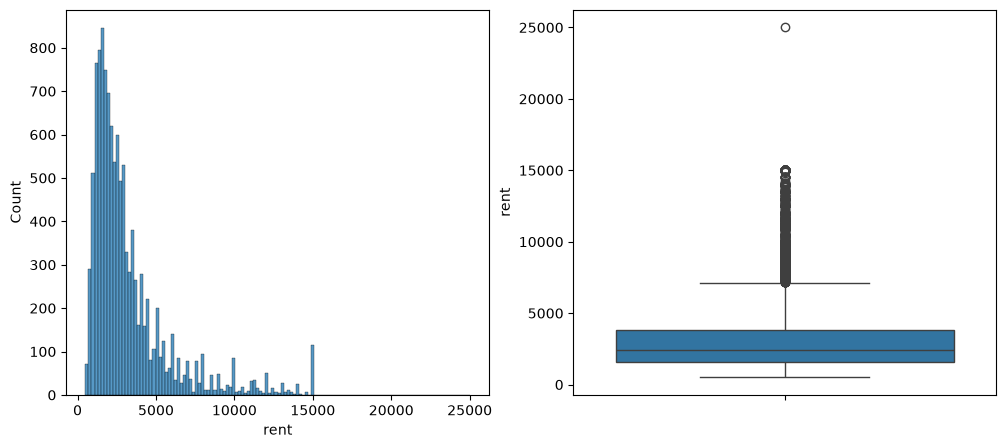

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

sns.histplot(data=df['rent'], ax=axes[0])
sns.boxplot(data=df['rent'], ax=axes[1])

plt.show()

In [5]:
print(f'A variável rent possui skweness de {df['rent'].skew()}')
print(f'A variável rent possui skweness de {df['rent'].kurt()}')


A variável rent possui skweness de 2.2749432261071942
A variável rent possui skweness de 5.89099765395145


O histograma da variável rent evidencia uma distribuição assimétrica à direita, com elevada concentração de imóveis em faixas de aluguel inferiores à média e próximas da mediana. Essa característica é corroborada pelo coeficiente de assimetria (skewness ≈ 2,275), indicando uma forte assimetria positiva e sugerindo que poucos imóveis de aluguel elevado deslocam a média para valores superiores à mediana.

Adicionalmente, a curtose (≈ 5,89) indica que a distribuição apresenta caudas mais pesadas do que uma distribuição normal, evidenciando maior ocorrência de valores extremos. Esse comportamento é compatível com a presença de imóveis de alto valor de aluguel, que se afastam significativamente do padrão predominante no conjunto de dados, o que pode ser confirmado pelo boxplot.

Em conjunto, essas evidências sugerem que a variável rent não segue uma distribuição aproximadamente normal. Essas características deverão ser consideradas nas etapas de preparação dos dados e modelagem, especialmente na avaliação da necessidade de transformações na variável resposta ou de técnicas robustas ao efeito de valores extremos.

## Variável Numérica Area

Como os valores de área estão distribuídos no conjunto de dados?

Como esta é uma variável física, valores que possuem área iguais a zero devem ser desconsiderados.

In [6]:
# Estatísticas Descritivas
df['area'].describe()

count    11657.000000
mean        84.655658
std         74.020536
min          0.000000
25%         40.000000
50%         60.000000
75%         96.000000
max        580.000000
Name: area, dtype: float64

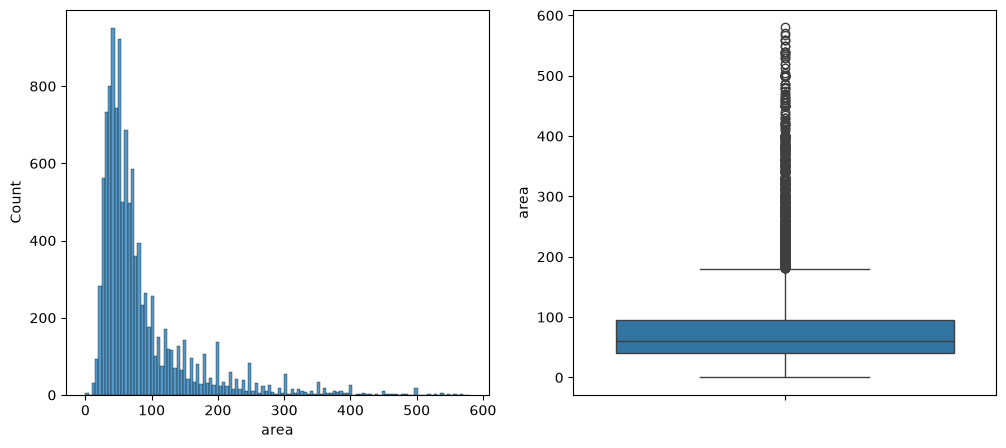

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

sns.histplot(data=df['area'], ax=axes[0])
sns.boxplot(data=df['area'], ax=axes[1])

plt.show()

In [8]:
print(f'A variável area possui skweness de {df['area'].skew()}')
print(f'A variável area possui skweness de {df['area'].kurt()}')

A variável area possui skweness de 2.6023088924770237
A variável area possui skweness de 8.394596310587264


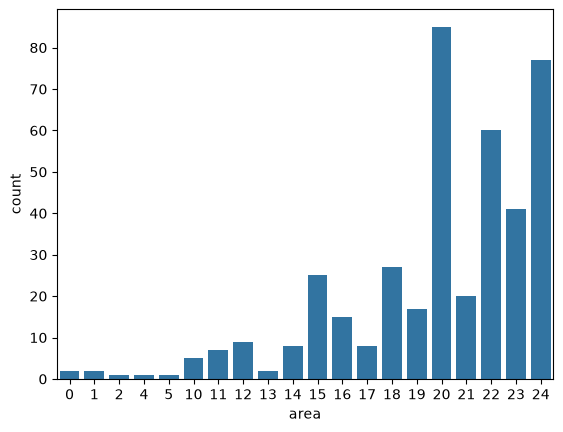

In [9]:
sns.barplot(df["area"].value_counts().sort_index().head(20))
plt.show()

In [10]:
df[df['area'] <= 5]

,address,district,area,bedrooms,garage,type,rent,total
962,Rua Engenheiro Bianor,Butantã,1,1,1,Studio e kitnet,2490,2987
1223,Rua Mussumés,Vila Maria Alta,5,1,0,Casa,570,594
2983,Rua Relíquia,Jardim das Laranjeiras,0,2,1,Apartamento,1600,2569
5323,Rua Solidônio Leite,Vila Ivone,2,2,2,Casa,2500,2711
7085,Rua Edmundo de Amicis,Morumbi,0,3,2,Casa,3200,3351
9898,Rua Visconde de Porto Seguro,Jardim dos Estados,1,4,3,Casa em condomínio,8500,11420
11055,Travessa Santa Filomena,Vila Campo Grande,4,1,0,Casa,630,641


A distribuição da variável `area` apresenta forte assimetria à direita, com elevada concentração de imóveis em áreas inferiores à média e próximas da mediana. Essa característica é corroborada pelo coeficiente de assimetria (skewness ≈ 2,60), indicando a existência de poucos imóveis com áreas significativamente superiores ao padrão predominante.

A curtose (≈ 8,39) reforça essa evidência, sugerindo uma distribuição com caudas pesadas e maior ocorrência de valores extremos. O boxplot confirma esse comportamento ao evidenciar diversas observações acima de aproximadamente 200 m².

Adicionalmente, a investigação das menores áreas registradas identificou imóveis com valores iguais a 0, 1, 2, 4 e 5 m². Analisando quais imóveis possuem áreas menores que 10 m², fica evidente que são valores impossíveis. Como o objetivo da EDA é caracterizar e compreender os dados, esses registros serão mantidos temporariamente. A decisão sobre sua remoção ou tratamento será tomada na etapa de preparação dos dados, após avaliar seu impacto no conjunto de dados e investigar possíveis padrões associados.

## Variável Numérica Bedrooms

Como os valores de quartos estão distribuídos no conjunto de dados?

Como esta é uma variável física, valores que possuem área iguais a zero devem ser entendidos baseado no negócio, isto é, depende-se do tipo de imóvel considerado.

In [11]:
# Estatísticas Descritivas
df['bedrooms'].describe()

count    11657.000000
mean         1.966286
std          0.931313
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: bedrooms, dtype: float64

In [12]:
df[(df['bedrooms'] == 0)]

,address,district,area,bedrooms,garage,type,rent,total
71,Rua Natividade Saldanha,São Lucas,22,0,0,Studio e kitnet,900,1126
98,Rua Natividade Saldanha,São Lucas,19,0,0,Studio e kitnet,850,1052
163,Rua João José Pacheco,Jardim Vila Mariana,22,0,0,Studio e kitnet,2200,2808
259,Rua Riskallah Jorge,Centro Histórico de São Paulo,28,0,0,Studio e kitnet,1207,1647
476,Rua Doutor Miguel Vieira Ferreira,Tatuapé,30,0,0,Apartamento,1840,2113
493,Rua Natividade Saldanha,São Lucas,32,0,0,Studio e kitnet,1200,1532
569,Rua Albino Boldasso Gabril,Vila Cruzeiro,44,0,0,Studio e kitnet,1400,1598
604,Rua Natividade Saldanha,São Lucas,29,0,0,Studio e kitnet,1150,1452
631,Avenida São João,Santa Cecilia,35,0,0,Studio e kitnet,935,1348
708,Rua Doutor Albuquerque Lins,Santa Cecília,63,0,0,Studio e kitnet,1600,2186


In [13]:
df[(df['bedrooms'] == 0) & (df['type'] == 'Studio e kitnet')].shape

(26, 8)

In [14]:
df[(df['bedrooms'] == 0) & (df['type'] == 'Apartamento')].shape

(7, 8)

In [15]:
df[(df['bedrooms'] == 0) & (df['type'] == 'Casa')].shape

(4, 8)

A variável bedrooms apresenta 37 registros com valor igual a zero. Entretanto, uma investigação conjunta com a variável type demonstra que essa situação nem sempre representa uma inconsistência.

Dos 37 registros, 26 correspondem a imóveis classificados como Studio e kitnet, categoria em que a ausência de quartos independentes é compatível com a configuração do imóvel. Assim, esses casos não são considerados inconsistentes.

Por outro lado, foram identificados sete apartamentos e quatro casas registrados com zero quartos. Embora parte dos apartamentos possa representar imóveis classificados incorretamente como Studio e kitnet, os registros referentes às casas configuram uma inconsistência evidente frente às características esperadas desse tipo de imóvel.

Essas observações serão consideradas na etapa de preparação dos dados, na qual será investigada a necessidade de corrigir, reclassificar ou remover esses registros.

## Variável Numérica Garage

Como os valores de garagem estão distribuídos no conjunto de dados?

In [16]:
# Estatísticas Descritivas
df['bedrooms'].describe()

count    11657.000000
mean         1.966286
std          0.931313
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: bedrooms, dtype: float64

In [17]:
df["garage"].value_counts().sort_index()

garage
0    4118
1    4574
2    1908
3     539
4     321
5     112
6      85
Name: count, dtype: int64

A variável `garage` representa o número de vagas de garagem disponíveis em cada imóvel e apresenta valores entre 0 e 6 vagas. Esses limites são compatíveis com o contexto do mercado imobiliário, não sendo identificados valores claramente inconsistentes.

A distribuição das frequências demonstra predominância de imóveis com zero ou uma vagag de garagem, enquanto imóveis com quatro ou mais vagas são pouco frequentes, caracterizando propriedades de padrão superior. Dessa forma, não foram identificadas evidências que justifiquem tratamentos específicos para essa variável na etapa de preparação dos dados.

## Variável Categórica type

Qual é a composição do mercado imobiliário presente no dataset?

Como `type` é uma variável categórica com poucas categorias, um gráfico de barras é adequado para visualizar sua distribuição e comparar a frequência de cada tipo de imóvel.

In [24]:
df['type'].value_counts(normalize=True)*100

type
Apartamento           61.713992
Casa                  24.371622
Studio e kitnet       11.846959
Casa em condomínio     2.067427
Name: proportion, dtype: float64

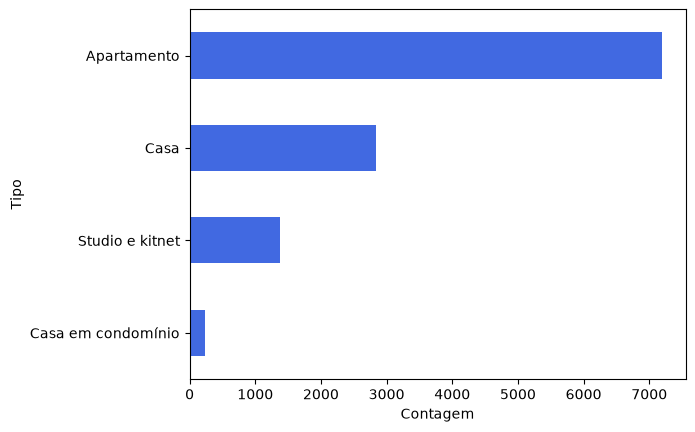

In [23]:
# Plota as barras horizontais
ax = df["type"].value_counts().plot.barh(color="royalblue")

# Inverte o eixo Y para a maior categoria ficar no topo
ax.invert_yaxis()

plt.xlabel("Contagem")
plt.ylabel("Tipo")
plt.show()

A distribuição da variável `type` demonstra predominância de apartamentos, representando aproximadamente 61,71% dos imóveis presentes no conjunto de dados. Em seguida aparecem casas, enquanto Studios e kitnets e Casas em condomínio representam parcelas menores.

Essa distribuição sugere que o conjunto de dados é fortemente composto por imóveis verticais, característica compatível com o perfil imobiliário da cidade de São Paulo. Como consequência, modelos treinados sobre esse conjunto poderão apresentar melhor capacidade de generalização para apartamentos do que para categorias menos frequentes.

## Variável Categórica district

Qual é a composição do mercado imobiliário presente no dataset?

Como `district` é uma variável categórica com muitas categorias, um gráfico de barras pode ser adequado para visualizar a distribuição dos bairros mais frequentes para entender o negócio.

Sabe-se que a variável categórica `district` possui **alta cardinalidade**, com 1999 registros únicos, o que pode prejudicar os modelos de Machine Learning.

In [46]:
# Quantos imóveis existem em cada bairro?
district_frequency = df["district"].value_counts()
print(district_frequency.head(20))

district
Bela Vista         352
Vila Mariana       232
Jardim Paulista    220
Centro             178
Pinheiros          159
Consolação         157
Santana            152
Mooca              147
Santo Amaro        146
Brás               141
Liberdade          141
Cerqueira César    140
Vila Andrade       129
República          123
Campos Elíseos     117
Vila Suzana        114
Perdizes           111
Campo Belo         108
Cambuci            104
Tatuapé             98
Name: count, dtype: int64


* `output`: quantos registros um determinado bairro possui?

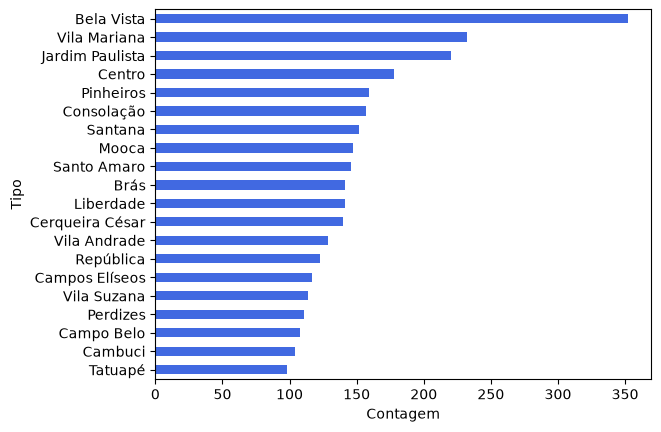

In [47]:
# Plota as barras horizontais
ax = df["district"].value_counts().head(20).plot.barh(color="royalblue")

ax.invert_yaxis()

plt.xlabel("Contagem")
plt.ylabel("Tipo")
plt.show()

In [ ]:
# Quantos imóveis existem por bairro??
district_frequency.value_counts().sort_index()

count
1      340
2      185
3      117
4       80
5       71
      ... 
159      1
178      1
220      1
232      1
352      1
Name: count, Length: 82, dtype: int64

A variável district apresenta alta cardinalidade, com 1.199 bairros distintos. Além disso, observa-se que diversos bairros possuem baixa frequência de ocorrência, aspecto que deverá ser considerado na etapa de engenharia de atributos e codificação das variáveis categóricas.

## Variável Categórica address

In [50]:
df["address"].nunique()

5348

A variável `address` apresenta elevada cardinalidade, sendo composta majoritariamente por endereços únicos. Embora contenha informações espaciais relevantes, sua utilização direta em modelos de Machine Learning tende a ser limitada devido à baixa repetição das categorias. Dessa forma, a variável não será explorada individualmente nesta etapa, podendo ser descartada ou transformada em atributos geográficos em trabalhos futuros.

---

# 2. Análise Bivariada (Estatística Relacional)

## 2.1 Relação entre variáveis numéricas

### 2.1.1 Área e Aluguel

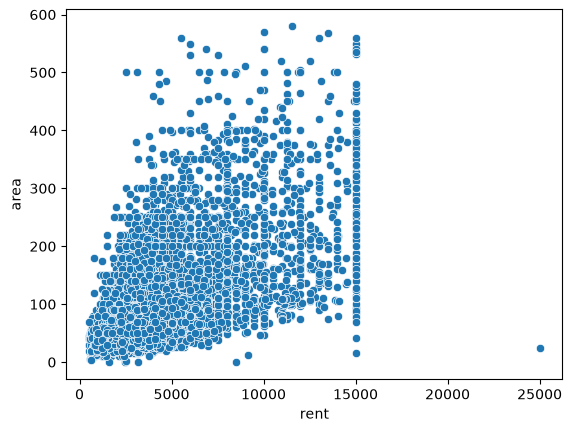

In [53]:
# Scatterplot
sns.scatterplot(data=df, x='rent', y='area')
plt.show()

In [56]:
# Coeficientes de correlação estatística

# Pearson mede associação linear: quanto maior uma variável, maior será a outra -> sensível a outliers
print(f'O coeficiente da correlação de Pearson é {df["area"].corr(df["rent"], method="pearson")}')

# Spearman mede associação monotônica: robusto à assimetrias, quando há outliers e a relação não é perfeitamente linear
print(f'O coeficiente da correlação de Spearman é {df["area"].corr(df["rent"], method="spearman")}')

O coeficiente da correlação de Pearson é 0.6671734126123198
O coeficiente da correlação de Spearman é 0.6221920146552585


In [57]:
df[df["rent"] == 15000]

,address,district,area,bedrooms,garage,type,rent,total
400,Rua Helena,Vila Olímpia,126,3,3,Apartamento,15000,17410
1354,Rua Michigan,Cidade Monções,158,3,3,Apartamento,15000,19530
1656,Rua Caminha de Amorim,Alto de Pinheiros,151,2,0,Casa,15000,16140
3145,Rua Casa do Ator,Vila Olímpia,93,2,2,Apartamento,15000,18090
3565,Avenida Jandira,Indianópolis,212,3,2,Apartamento,15000,17250
...,...,...,...,...,...,...,...,...
11591,Rua Leonardo Cerveira Varandas,Paraíso do Morumbi,300,3,3,Apartamento,15000,18580
11599,Rua Forte William,Jardim Fonte do Morumbi,232,4,5,Apartamento,15000,19520
11603,Rua Domênico Perotti,Jardim Fonte do Morumbi,280,4,5,Apartamento,15000,23180
11637,Alameda Calicut,Chácara Santo Antônio,430,4,4,Casa,15000,17200


In [58]:
df[df["rent"] == 25000]

,address,district,area,bedrooms,garage,type,rent,total
6095,Avenida Chibarás,Planalto Paulista,24,1,0,Studio e kitnet,25000,26710


O gráfico de dispersão evidencia uma associação positiva entre a área do imóvel e o valor do aluguel, indicando que imóveis maiores tendem, em média, a apresentar aluguéis mais elevados. Entretanto, observa-se elevada dispersão dos valores para imóveis de áreas semelhantes, sugerindo que outros fatores, como localização e tipo do imóvel, também exercem influência significativa sobre o preço.

Além disso, verifica-se um aumento da variabilidade do aluguel à medida que a área cresce, caracterizando um padrão de heterocedasticidade. Esse comportamento indica que a relação entre as variáveis não é perfeitamente linear e que imóveis de maior porte apresentam maior diversidade de preços.

Os coeficientes de Pearson (0,667) e Spearman (0,622) corroboram essa interpretação, evidenciando uma associação positiva moderada entre as variáveis. A proximidade entre os dois coeficientes sugere que a relação observada permanece consistente mesmo considerando a presença de outliers e distribuições assimétricas.

Por fim, destacam-se concentrações de imóveis com aluguel exatamente igual a R$ 15.000 e um registro de aluguel de R$ 25.000 para uma área relativamente pequena. A investigação dos imóveis com aluguel igual a R$ 15.000 revelou registros distribuídos entre diferentes bairros, áreas e tipos de imóveis, não sendo identificados padrões que permitam classificá-los como inconsistências. Embora a concentração nesse valor possa decorrer de características da plataforma utilizada para a coleta dos dados, essa hipótese não pode ser confirmada apenas com as informações disponíveis.

Também foi identificado um único imóvel com aluguel de R$ 25.000 e área relativamente reduzida. Apesar de representar uma observação extrema, não existem evidências suficientes para tratá-lo como erro de cadastro. Dessa forma, ambos os casos serão mantidos no conjunto de dados nesta etapa e sua influência será reavaliada durante a construção e validação dos modelos preditivos.

### 2.1.2 Quartos e Aluguel

Espera-se que imóveis com maior número de quartos apresentem, em média, maiores valores de aluguel, embora essa relação não seja necessariamente linear, pois fatores como área, localização e tipo do imóvel também influenciam significativamente o preço.

In [61]:
df.groupby("bedrooms")["rent"].describe()

,count,mean,std,min,25%,50%,75%,max
bedrooms,,,,,,,,
0,37.0,2236.783784,2470.995820,850.0,1050.0,1400.0,2200.0,12500.0
1,4193.0,2153.957548,1526.092789,500.0,1196.0,1711.0,2700.0,25000.0
2,4347.0,2749.275362,1828.050977,500.0,1650.0,2200.0,3120.0,15000.0
3,2423.0,4795.238960,3038.859035,900.0,2720.0,3800.0,5812.0,15000.0
4,543.0,7806.267035,3652.366636,1890.0,4700.0,7200.0,10000.0,15000.0
5,91.0,8568.252747,3496.669948,2400.0,5805.0,8000.0,11760.0,15000.0
6,23.0,8346.304348,3698.932960,3000.0,5562.5,8000.0,10800.0,15000.0


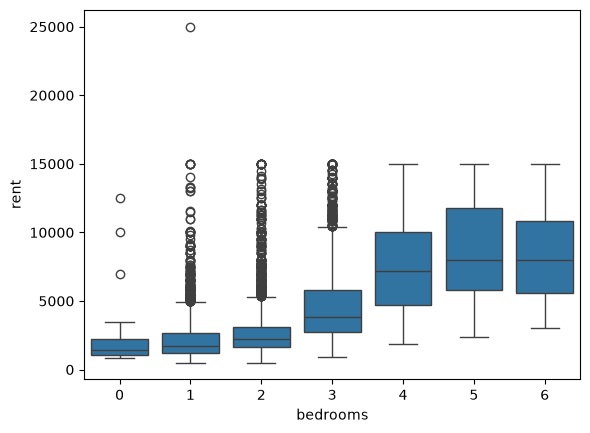

In [60]:
# Scatterplot
sns.boxplot(
    data=df,
    x='bedrooms',
    y='rent'
)
plt.show()

In [63]:
df.groupby("bedrooms")["type"].value_counts()

bedrooms  type              
0         Studio e kitnet         26
          Apartamento              7
          Casa                     4
1         Apartamento           2047
          Studio e kitnet       1320
          Casa                   762
          Casa em condomínio      64
2         Apartamento           3419
          Casa                   798
          Casa em condomínio      96
          Studio e kitnet         34
3         Apartamento           1482
          Casa                   892
          Casa em condomínio      49
4         Casa                   291
          Apartamento            227
          Casa em condomínio      25
5         Casa                    75
          Apartamento             10
          Casa em condomínio       6
6         Casa                    19
          Apartamento              2
          Studio e kitnet          1
          Casa em condomínio       1
Name: count, dtype: int64

In [62]:
df[
    (df["bedrooms"] == 0) &
    (df["rent"] > 5000)
]

,address,district,area,bedrooms,garage,type,rent,total
9501,Rua Dom Armando Lombardi,Vila Progredior,250,0,3,Casa,10000,10290
10062,Rua Graúna,Vila Uberabinha,141,0,0,Casa,7000,7208
10082,Rua Conde de Porto Alegre,Campo Belo,200,0,4,Casa,12500,12790


O boxplot evidencia uma tendência crescente entre o número de quartos e o valor do aluguel, indicando que imóveis com maior quantidade de dormitórios tendem, em média, a apresentar preços mais elevados. Essa tendência é observada pelo aumento progressivo da mediana entre os grupos de quartos, corroborando a hipótese inicial de que imóveis maiores possuem maior valor de aluguel.

Além do aumento da mediana, observa-se também um crescimento da dispersão dos valores de aluguel à medida que aumenta o número de quartos. Os grupos com quatro, cinco e seis dormitórios apresentam caixas e whiskers significativamente maiores, indicando maior heterogeneidade dos preços. Esse comportamento sugere que imóveis maiores pertencem a segmentos bastante distintos do mercado imobiliário, desde residências amplas até imóveis de alto padrão.

Os grupos de um, dois e três quartos apresentam elevada quantidade de outliers superiores, refletindo a existência de imóveis com valores de aluguel muito acima da mediana. Destaca-se novamente a concentração de imóveis com aluguel igual a R$ 15.000, reforçando a hipótese levantada anteriormente de um possível comportamento associado à plataforma utilizada para a coleta dos dados. Também é observado o imóvel com aluguel de R$ 25.000, já investigado durante a análise da variável rent.

A análise conjunta entre o número de quartos e o tipo do imóvel ajuda a explicar parte da distribuição observada. Imóveis com quatro ou mais dormitórios são compostos majoritariamente por casas e casas em condomínio, enquanto apartamentos predominam entre imóveis de um, dois e três quartos. Esse comportamento é consistente com a realidade do mercado imobiliário, uma vez que residências maiores tendem a apresentar maior área construída e maior variabilidade de preço.

Por outro lado, os registros com zero quartos são compostos predominantemente por Studios e kitnets (26 dos 37 imóveis), justificando naturalmente a existência desse grupo. Entretanto, também foram identificados sete apartamentos e quatro casas cadastrados com zero quartos, configurando registros potencialmente inconsistentes que deverão ser tratados na etapa de preparação dos dados.

### 2.1.3 Garagem e Aluguel

In [64]:
df.groupby('garage')['rent'].describe()

,count,mean,std,min,25%,50%,75%,max
garage,,,,,,,,
0,4118.0,1847.711510,1198.612821,500.0,1158.0,1524.5,2200.0,25000.0
1,4574.0,2914.988850,1817.782291,650.0,1800.0,2446.0,3500.0,15000.0
2,1908.0,4740.867400,2714.002619,999.0,2900.0,3935.0,5800.0,15000.0
3,539.0,6813.901670,3466.490188,1300.0,4000.0,6000.0,9000.0,15000.0
4,321.0,7985.174455,3794.488778,1600.0,4836.0,7500.0,10950.0,15000.0
5,112.0,8422.544643,4391.805949,1978.0,4425.0,8320.0,12045.0,15000.0
6,85.0,8563.282353,3965.995061,2300.0,5000.0,8430.0,11850.0,15000.0


In [66]:
df['garage'].value_counts().sort_index()

garage
0    4118
1    4574
2    1908
3     539
4     321
5     112
6      85
Name: count, dtype: int64

In [69]:
df.groupby("garage")["type"].value_counts()

garage  type              
0       Apartamento           2008
        Studio e kitnet       1039
        Casa                   989
        Casa em condomínio      82
1       Apartamento           3600
        Casa                   593
        Studio e kitnet        325
        Casa em condomínio      56
2       Apartamento           1176
        Casa                   652
        Casa em condomínio      64
        Studio e kitnet         16
3       Apartamento            272
        Casa                   252
        Casa em condomínio      14
        Studio e kitnet          1
4       Casa                   197
        Apartamento            109
        Casa em condomínio      15
5       Casa                    85
        Apartamento             22
        Casa em condomínio       5
6       Casa                    73
        Apartamento              7
        Casa em condomínio       5
Name: count, dtype: int64

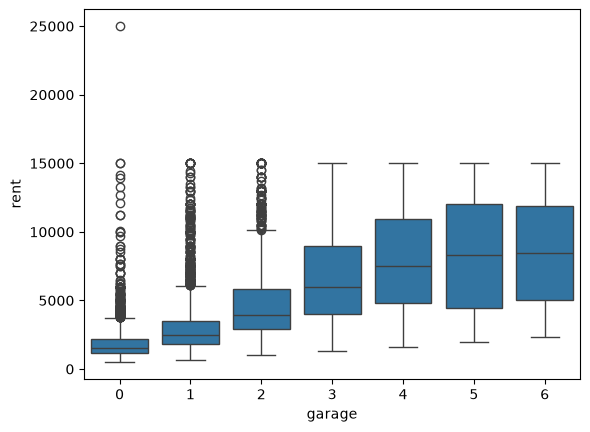

In [67]:
sns.boxplot(
    data=df,
    x='garage',
    y='rent'
)
plt.show()

In [68]:
df.groupby('garage')['type'].value_counts()

garage  type              
0       Apartamento           2008
        Studio e kitnet       1039
        Casa                   989
        Casa em condomínio      82
1       Apartamento           3600
        Casa                   593
        Studio e kitnet        325
        Casa em condomínio      56
2       Apartamento           1176
        Casa                   652
        Casa em condomínio      64
        Studio e kitnet         16
3       Apartamento            272
        Casa                   252
        Casa em condomínio      14
        Studio e kitnet          1
4       Casa                   197
        Apartamento            109
        Casa em condomínio      15
5       Casa                    85
        Apartamento             22
        Casa em condomínio       5
6       Casa                    73
        Apartamento              7
        Casa em condomínio       5
Name: count, dtype: int64

O boxplot evidencia uma associação positiva entre o número de vagas de garagem e o valor do aluguel. Observa-se um aumento progressivo da mediana dos preços conforme cresce a quantidade de vagas, indicando que imóveis com mais garagens tendem a pertencer a segmentos de maior valor agregado.

Além do crescimento da mediana, verifica-se também um aumento da dispersão dos preços de aluguel para imóveis com maior número de vagas. As caixas e os whiskers tornam-se progressivamente maiores a partir de duas vagas, indicando maior heterogeneidade entre esses imóveis. Esse comportamento sugere que, à medida que aumenta o padrão do imóvel, outros fatores além da garagem — como área construída, localização e padrão construtivo — passam a exercer influência significativa sobre o preço.

A análise conjunta entre o número de vagas e o tipo do imóvel explica parte desse comportamento. Observa-se que imóveis sem garagem e com apenas uma vaga são predominantemente apartamentos, enquanto imóveis com quatro ou mais vagas passam a ser compostos majoritariamente por casas. Essa mudança de perfil ajuda a justificar tanto o aumento da mediana quanto o crescimento da variabilidade dos preços, uma vez que residências costumam apresentar maior diversidade de área, localização e padrão construtivo quando comparadas aos apartamentos.

Também é possível observar que a mediana tende a estabilizar entre cinco e seis vagas de garagem. Esse comportamento sugere que, para imóveis de alto padrão, o número de vagas deixa de ser um fator determinante na precificação, sendo substituído por outras características que agregam maior valor ao imóvel.

Por fim, foram identificados alguns registros extremos, como o imóvel com aluguel de R$ 25.000 sem vaga de garagem e um imóvel com seis vagas e aluguel de aproximadamente R$ 2.300. Embora esses casos mereçam investigação, não existem evidências suficientes para classificá-los como inconsistências nesta etapa do projeto, permanecendo no conjunto de dados para posterior avaliação durante a modelagem.

### Hipótese para Engenharia de Atributos

Durante a análise exploratória, observou-se que imóveis com quatro ou mais vagas de garagem são compostos majoritariamente por casas, enquanto apartamentos predominam entre imóveis com até três vagas. Além disso, esses imóveis apresentam medianas de aluguel significativamente superiores e maior dispersão dos preços, indicando que pertencem, em geral, ao segmento de médio e alto padrão do mercado imobiliário.

Esse comportamento sugere que o número de vagas de garagem não representa apenas uma característica física do imóvel, mas também pode atuar como um indicador indireto do padrão do imóvel.

Dessa forma, uma hipótese para a etapa de *Feature Engineering* é a criação de uma variável binária que identifique imóveis de possível alto padrão, por exemplo:

- `high_standard = (garage >= 4)`

ou ainda uma variável que combine múltiplas características, como:

- `high_standard = (garage >= 4) AND (type == 'Casa')`

Essa hipótese **não será aplicada neste momento**, pois ainda depende da análise das demais variáveis e da etapa de preparação dos dados. Caso implementada, sua contribuição deverá ser validada objetivamente durante a modelagem, comparando o desempenho dos modelos com e sem essa nova variável.

### 2.1.4 Valor total e Aluguel

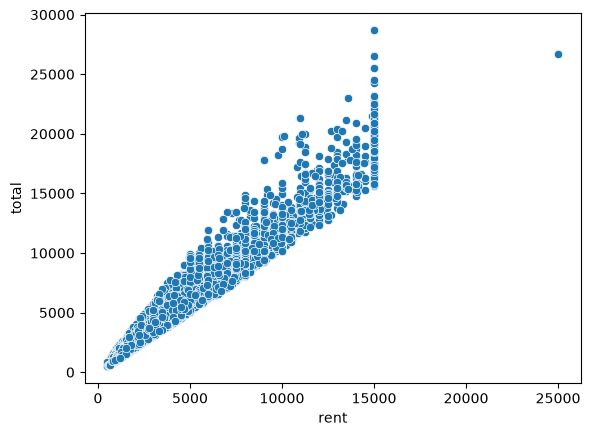

In [79]:
sns.scatterplot(
    data=df,
    x="rent",
    y="total"
)
plt.show()

In [71]:
df[['rent','total']].corr()

,rent,total
rent,1.000000,0.978108
total,0.978108,1.000000


A forte correlação entre rent e total era esperada, uma vez que o valor total é composto pelo próprio aluguel acrescido de condomínio, IPTU e outras taxas. A diferença entre essas variáveis representa os custos adicionais do imóvel, que podem refletir características como infraestrutura do condomínio e localização. Apesar do potencial interesse analítico, essa informação não será utilizada como variável explicativa na modelagem, pois depende diretamente da variável-alvo (rent), caracterizando vazamento de informação (**data leakage**).

## 2.2 Relação entre variáveis categóricas e numéricas

### 2.2.1 Tipos de imóveis e Aluguel

O tipo de imóvel influencia o valor do aluguel?

In [80]:
df.groupby("type")["rent"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Apartamento,7194.0,3356.902697,2638.994113,567.0,1700.0,2500.0,3899.75,15000.0
Casa,2841.0,3471.924674,2873.786579,500.0,1380.0,2600.0,4500.00,15000.0
Casa em condomínio,241.0,3912.551867,3930.906662,504.0,1400.0,2200.0,4000.00,15000.0
Studio e kitnet,1381.0,2127.825489,1365.744349,500.0,1200.0,1850.0,2790.00,25000.0


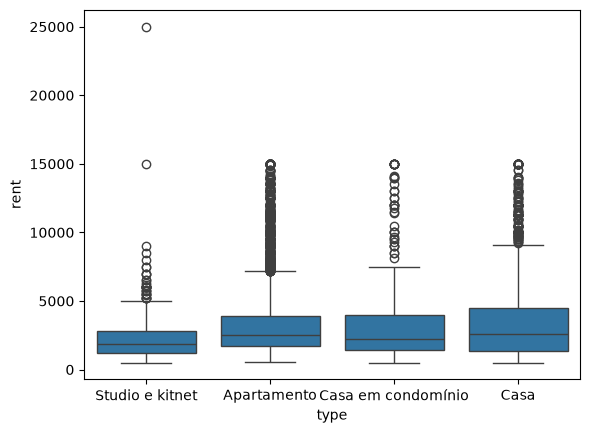

In [81]:
sns.boxplot(
    data=df,
    x="type",
    y="rent"
)
plt.show()

A análise conjunta entre o tipo do imóvel e o valor do aluguel evidencia diferenças importantes entre as categorias. Os Studios e kitnets apresentam a menor mediana de aluguel (R$ 1.850), além da menor dispersão dos preços, comportamento esperado devido às menores áreas e ao público-alvo desse tipo de imóvel.

Apartamentos e casas apresentam medianas bastante próximas (R$ 2.500 e R$ 2.600, respectivamente), porém as casas exibem maior variabilidade dos valores de aluguel, indicando maior heterogeneidade do mercado. Essa diferença pode ser explicada pela maior diversidade de áreas, localizações e padrões construtivos encontrados entre as residências.

Embora fosse esperado que Casas em condomínio apresentassem os maiores valores de aluguel, observa-se uma mediana de aproximadamente R$ 2.200, inferior à observada para casas e apartamentos. Entretanto, essa categoria possui apenas 241 registros e apresenta o maior desvio-padrão entre todos os grupos, sugerindo elevada heterogeneidade. Esse comportamento indica que nem todas as casas em condomínio pertencem ao segmento de alto padrão, coexistindo imóveis relativamente acessíveis e imóveis de luxo dentro dessa mesma categoria.

Por fim, observa-se elevada quantidade de outliers superiores para apartamentos, casas e casas em condomínio, indicando a presença de imóveis significativamente mais caros que a maioria do mercado. Esses registros representam uma característica natural da distribuição dos preços e reforçam a existência de diferentes segmentos do mercado imobiliário no conjunto de dados.

### 2.2.2 Tipos de imóveis e área

In [82]:
df.groupby("type")["area"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Apartamento,7194.0,73.318460,50.859956,0.0,45.0,60.0,81.0,568.0
Casa,2841.0,136.136220,101.794391,0.0,60.0,110.0,180.0,580.0
Casa em condomínio,241.0,119.414938,113.205206,1.0,50.0,75.0,140.0,560.0
Studio e kitnet,1381.0,31.742216,10.125382,1.0,25.0,30.0,37.0,130.0


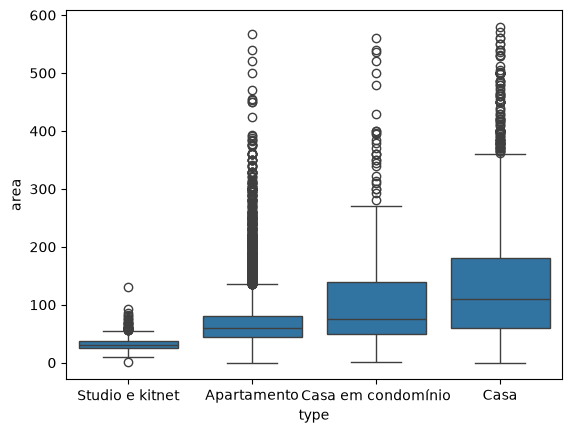

In [83]:
sns.boxplot(
    data=df,
    x="type",
    y="area"
)
plt.show()

Os apartamentos apresentam elevada variabilidade de área, indicando que essa categoria contempla desde imóveis compactos até apartamentos de alto padrão. Esse comportamento ajuda a explicar a grande dispersão observada anteriormente nos valores de aluguel dessa categoria.

### 2.2.3 Quais bairros possuem maior aluguel?

In [84]:
district_rent = (
    df.groupby("district")["rent"]
      .median()
      .sort_values(ascending=False)
)

district_rent.head(20)

district
Alphaville Residencial Dois          15000.0
Alphaville Residencial Plus          15000.0
Jardim Tango                         15000.0
Residencial Cinco (alphaville)       13600.0
Alphaville Residencial Um            13500.0
Cidade Jardim                        13000.0
Alphaville                           12500.0
Chácara Santo Antônio                12000.0
Chácara Meyer                        12000.0
Centro Empresarial Tamboré           12000.0
Jardim Vitoria Regia (zona Oeste)    11820.0
Pacaembu                             11520.0
Jardim Cordeiro                      11250.0
Jardim dos Estados                   11250.0
Chácara Monte Alegre                 10625.0
Residencial Seis (alphaville)        10500.0
Vila Inah                            10500.0
Vila Irmaos Arnoni                   10000.0
Jardim do Colégio (zona Norte)       10000.0
Jardim Santa Helena                   9700.0
Name: rent, dtype: float64

In [87]:
district_rent.tail(20)

district
Vila Progresso (zona Norte)    813.0
Ponte Pequena                  807.0
Jardim Rosana                  800.0
Canhema                        800.0
Jardim Tietê                   800.0
Jardim Palmira                 794.5
Vila Serralheiro               770.0
Jardim Frei Galvao             770.0
Vila Cosmopolita               770.0
Jardim Vergueiro               759.0
Jardim Miriam                  750.0
Sítio do Piqueri               750.0
Vila São Luís                  740.0
Vila Ramos                     710.0
Vila Cardoso Franco            700.5
Vila Lais                      660.0
Jardim Maraba                  630.0
Jardim Frei Galvão             629.0
Jardim Inga                    600.0
Jardim Jaçanã                  500.0
Name: rent, dtype: float64

A variável `district` aparenta possuir elevado poder explicativo e deverá ser mantida durante a modelagem.

## 3.1 Correlação entre variáveis

<Axes: >

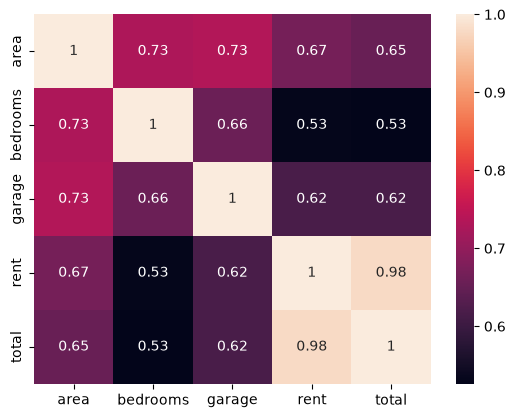

In [88]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

O mapa de correlação confirma quantitativamente as relações observadas durante a Análise Exploratória dos Dados. A variável rent apresenta forte correlação positiva com area (0,67), garage (0,62) e bedrooms (0,53), indicando que imóveis maiores, com maior número de quartos e vagas de garagem tendem a apresentar valores de aluguel mais elevados.

Destaca-se ainda que area apresenta elevada correlação tanto com bedrooms quanto com garage (0,73 em ambos os casos), sugerindo que imóveis maiores geralmente possuem mais cômodos e vagas de estacionamento. Esses resultados reforçam a hipótese de que essas características descrevem conjuntamente o padrão construtivo do imóvel.

Por fim, observa-se uma correlação extremamente elevada entre rent e total (0,98), comportamento esperado, uma vez que o valor total é composto pelo próprio aluguel acrescido de condomínio, IPTU e outras taxas. Por esse motivo, a variável total deverá ser analisada com cautela na etapa de modelagem, devido ao potencial risco de vazamento de informação (data leakage).

---

# 📌 Hipóteses levantadas durante a EDA

Ao longo da Análise Exploratória de Dados (EDA), algumas evidências sugerem possíveis decisões que poderão ser avaliadas durante as etapas de Preparação dos Dados (*Data Preparation*) e Engenharia de Atributos (*Feature Engineering*). As hipóteses apresentadas abaixo **não representam decisões definitivas**, mas sim observações que deverão ser validadas durante a construção dos modelos de Machine Learning.

---

### Hipótese 1 — Tratamento de registros inconsistentes

Foram identificados registros cuja área construída é igual ou inferior a 5 m², bem como apartamentos e casas cadastrados com zero quartos. Esses casos representam inconsistências do ponto de vista do domínio do problema e poderão ser removidos ou corrigidos durante a etapa de preparação dos dados, caso seja confirmado que não correspondem a situações reais.

---

### Hipótese 2 — Concentração de imóveis com aluguel igual a R$ 15.000

Observou-se uma concentração incomum de imóveis com aluguel exatamente igual a R$ 15.000. Apesar de esses imóveis apresentarem diferentes áreas, bairros e tipos de imóvel, esse comportamento pode estar relacionado a um limite imposto pela plataforma utilizada para a coleta dos dados ou apenas representar uma concentração natural do mercado imobiliário. Caso essa concentração afete o treinamento dos modelos, sua influência deverá ser investigada posteriormente.

---

### Hipótese 3 — Registro extremo de aluguel

Foi identificado um único imóvel do tipo *Studio e kitnet* com aluguel de R$ 25.000 e área relativamente pequena. Embora esse registro seja estatisticamente extremo, não existem evidências suficientes para classificá-lo como erro de cadastro. Sua permanência ou remoção deverá ser avaliada durante a etapa de modelagem.

---

### Hipótese 4 — Variável indicadora de imóveis de alto padrão

As análises conjuntas entre número de quartos, número de vagas de garagem e tipo do imóvel mostraram que imóveis com quatro ou mais vagas são predominantemente casas e apresentam medianas de aluguel significativamente superiores. Esse comportamento sugere que essas características podem representar um indicador indireto de imóveis de alto padrão.

Uma possível abordagem para a etapa de Engenharia de Atributos consiste em avaliar a criação de uma variável binária, por exemplo:

- `high_standard = (garage >= 4)`

ou

- `high_standard = (garage >= 4) AND (type == 'Casa')`

Essa hipótese deverá ser validada comparando o desempenho dos modelos com e sem essa nova variável.

---

### Hipótese 5 — Influência conjunta das variáveis explicativas

As análises realizadas indicam que nenhuma variável explica isoladamente o valor do aluguel. Características como área, número de quartos, quantidade de vagas de garagem, tipo do imóvel e localização parecem atuar de forma complementar na formação dos preços. Dessa forma, espera-se que modelos de Machine Learning consigam capturar melhor essas relações do que análises univariadas.

---

### Hipótese 6 - Custos adicionais do imóvel

A diferença entre total e rent representa os custos mensais adicionais do imóvel (condomínio, IPTU e demais taxas). Embora essa variável possa fornecer informações sobre o padrão do imóvel, ela depende diretamente da variável-alvo (rent) e, portanto, caracteriza vazamento de informação (data leakage). Dessa forma, essa transformação não será utilizada na modelagem preditiva, permanecendo apenas como um insight obtido durante a EDA.

---

### Hipótese 7 — O tipo do imóvel influencia o aluguel de forma indireta

A análise entre `type` e `rent` mostrou diferenças entre as categorias de imóveis, sendo os Studios e kitnets aqueles com menores medianas de aluguel e menor variabilidade dos preços. Apartamentos e casas apresentaram medianas semelhantes, enquanto casas em condomínio exibiram elevada dispersão dos valores.

Esse comportamento sugere que o tipo do imóvel influencia o valor do aluguel, porém de forma indireta, refletindo diferenças em outras características estruturais, como área construída, número de quartos, vagas de garagem e padrão construtivo.

Dessa forma, espera-se que a variável `type` contribua para o desempenho dos modelos de Machine Learning quando utilizada em conjunto com as demais variáveis explicativas.

---

### Hipótese 8 — O bairro representa um importante fator de localização

A análise da mediana dos aluguéis por bairro mostrou diferenças expressivas entre as regiões da cidade, indicando que a localização exerce influência relevante sobre o valor dos imóveis.

Embora não tenha sido realizada uma análise detalhada das características socioeconômicas de cada bairro, espera-se que a variável `district` apresente elevado poder explicativo durante a modelagem, uma vez que regiões distintas refletem diferenças de infraestrutura, acessibilidade, segurança e valorização imobiliária.

Entretanto, devido à elevada cardinalidade dessa variável (1.199 bairros distintos), será necessário avaliar estratégias de tratamento durante a etapa de Preparação dos Dados, como agrupamento de categorias pouco frequentes ou técnicas adequadas de codificação para variáveis categóricas.